# 01 - Exploratory Data Analysis (EDA)
## Đề tài 11: Phân tích đánh giá khách sạn & chủ đề dịch vụ

**Mục tiêu:**
- Khám phá và phân tích dữ liệu đánh giá khách sạn
- Trực quan hóa phân phối rating và sentiment
- Phân tích đặc điểm văn bản (text statistics)

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Enable inline plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from src.data.loader import load_data
from src.visualization.plots import PlotGenerator

[WARNING] HDBSCAN not available. Install with: pip install hdbscan


## 1. Load Data

In [2]:
# Load data
df = load_data(n_rows=2000)
print(f"Loaded {len(df)} reviews")
df.head()

[WARNING] Config file not found at configs\params.yaml
Using default configuration...
[INFO] File not found at data\raw\hotel_reviews.csv
[INFO] Generating sample hotel reviews data...
[INFO] Generating 2000 sample hotel reviews...
[INFO] Generated 2000 sample reviews
[INFO] Rating distribution:
rating
1    147
2    208
3    579
4    477
5    589
Name: count, dtype: int64
Loaded 2000 reviews


,review_text,rating,sentiment,reviewer_name,date,hotel_name
0,The room was nice but the noise from the stree...,4,mixed,Jennifer L.,2020-07-09,Royal Gardens Hotel
1,"Overall, perfect getaway! the hotel exceeded ...",4,positive,Laura B.,2022-06-07,City Center Suites
2,The room was clean but small. The location was...,3,neutral,Kevin J.,2023-08-15,Ocean Breeze Resort
3,"The room was spotless, the bed was comfortable...",5,positive,James W.,2020-02-12,Luxury Stay Hotel
4,"Considering everything, the room was clean bu...",3,neutral,Kevin J.,2020-07-08,Mountain View Inn


## 2. Rating Distribution

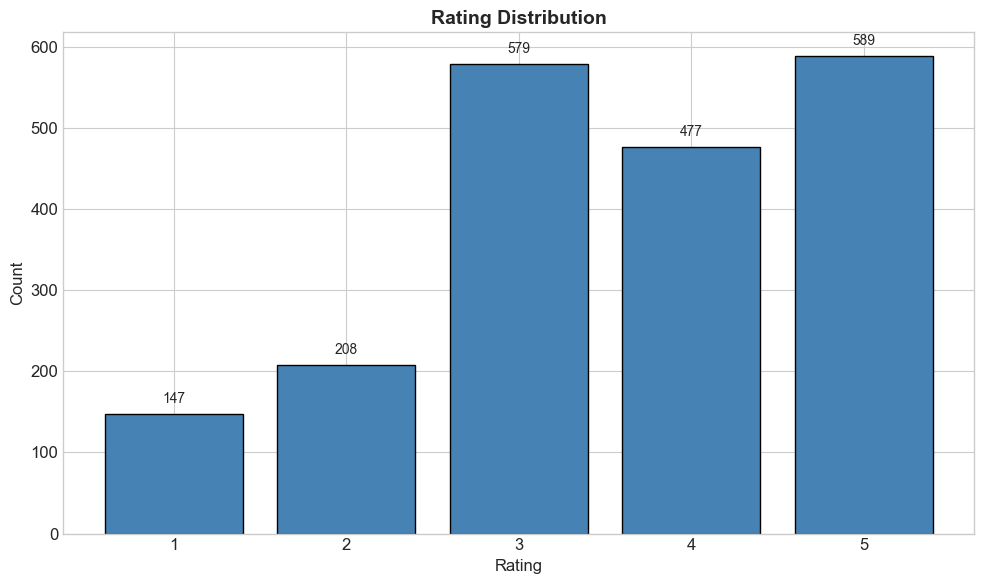

In [3]:
# Plot rating distribution
fig, ax = plt.subplots(figsize=(10, 6))
rating_counts = df['rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Sentiment Distribution

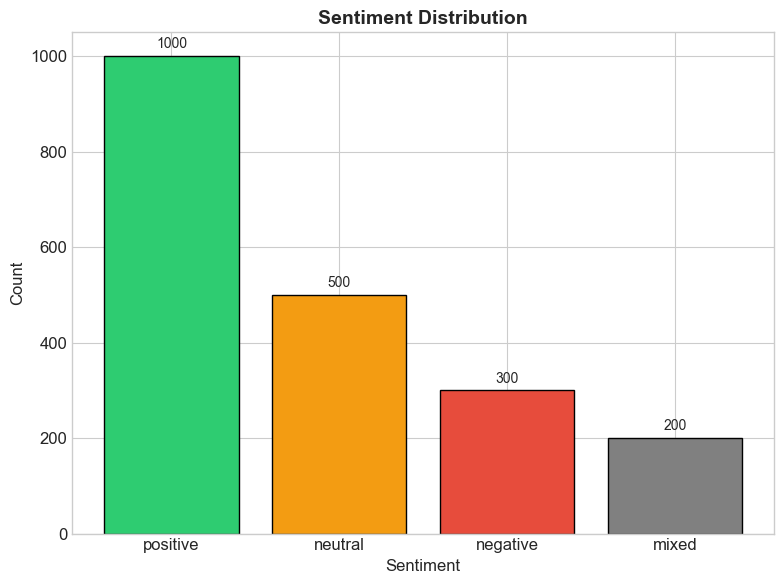

In [4]:
# Plot sentiment distribution
fig, ax = plt.subplots(figsize=(8, 6))
sentiment_counts = df['sentiment'].value_counts()
colors = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
bars = ax.bar(sentiment_counts.index, sentiment_counts.values, 
             color=[colors.get(s, 'gray') for s in sentiment_counts.index],
             edgecolor='black')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Rating by Sentiment

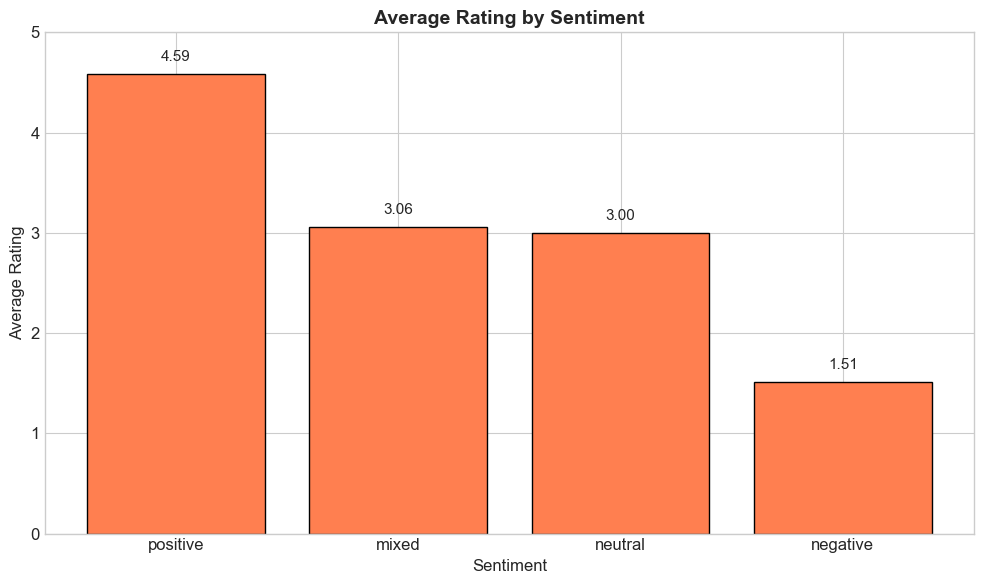

In [5]:
# Rating by sentiment
fig, ax = plt.subplots(figsize=(10, 6))
sentiment_rating = df.groupby('sentiment')['rating'].mean().sort_values(ascending=False)
bars = ax.bar(sentiment_rating.index, sentiment_rating.values, color='coral', edgecolor='black')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)
ax.set_title('Average Rating by Sentiment', fontsize=14, fontweight='bold')
ax.set_ylim(0, 5)
for bar, val in zip(bars, sentiment_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{val:.2f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Text Length Distribution

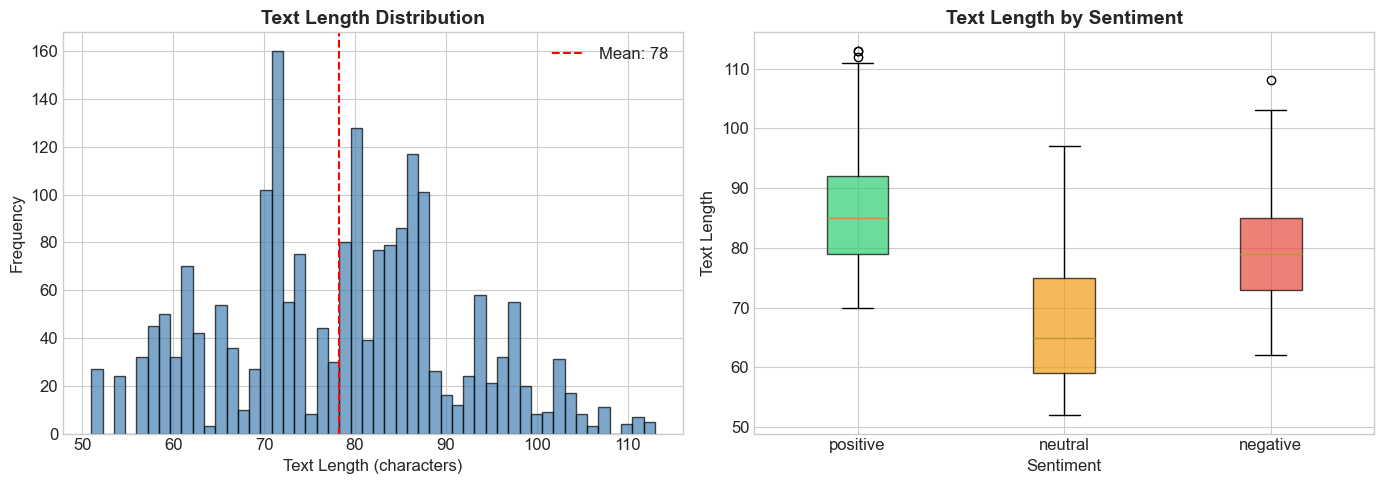

In [6]:
# Text length distribution
df['text_length'] = df['review_text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Text Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
axes[0].legend()

# Boxplot by sentiment
sentiments = ['positive', 'neutral', 'negative']
data_boxplot = [df[df['sentiment']==s]['text_length'].values for s in sentiments]
bp = axes[1].boxplot(data_boxplot, labels=sentiments, patch_artist=True)
colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Text Length', fontsize=12)
axes[1].set_title('Text Length by Sentiment', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()